# Vignette 3: Analysis of Macrophage Behavior in Responding Patients

This vignette examines macrophage populations and their behavior in responding patients, comparing core biopsies with surgical specimens. The analysis focuses on spatial distribution and gene expression patterns of tumor-associated macrophages (TAMs).

In [1]:
# USER DEFINED VARIABLES

LICENSE_FILE = "/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic"
DATA_FOLDER = "/ix1/alee/LO_LAB/General/Lab_Data/20250210_CITEGeistPublicData_GEO_Alex/processed_files/"

In [2]:
import os

# Core Biopsies
biopsy_responding_paths = [
    os.path.join(DATA_FOLDER, "HCC22-088-P2-S1/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P3-S1_A/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P5-S1/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P6-S1/outs"),
]

# Surgical Specimens Only For Now
surg_responding_paths = [
    os.path.join(DATA_FOLDER, "HCC22-088-P2-S2/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P3-S2/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P5-S2_F_rep/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P6-S2_D/outs"),
]

In [ ]:
import importlib
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

In [ ]:
import importlib

import model
import scanpy as sc

importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module

# Reload the model module if you're actively developing

## Cell Type Profile Definition

We define comprehensive cell profiles with antibody markers for major cell populations:
- Cancer Cells: EPCAM-1 (major), SDC1-1 and KRT5-1 (minor)
- Macrophages: CD68-1 (major), CD14-1 (minor)
- T Cells: CD3E-1 with CD4-1 or CD8A-1 (major)
- B Cells: MS4A1-1, CD19-1 (major)
- Stromal Cells: PECAM1-1 (endothelial), ACTA2-1 (fibroblasts)

In [4]:
cell_profiles = {
    "Cancer Cells": {"Major": ["EPCAM-1"], "Minor": ["SDC1-1", "KRT5-1"]},  # CD138 - possible cancer stem cell marker
    "Macrophages": {
        "Major": ["CD68-1"],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"],  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    },
}

## Data Loading and Initial Setup

We analyze spatial transcriptomics data from two cohorts:
1. Core Biopsies: Four patient samples from pre-treatment biopsies
2. Surgical Specimens: Four matched surgical samples post-treatment

Each dataset is processed using CITEgeist for spatial deconvolution and cell type identification.

## Core Biopsies

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 4860 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 2256
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
Set parameter GURO_PAR_SPECIAL
Set parameter TokenServer to value "10.201.0.113"


Refining Cell Proportions: 100%|██████████| 2256/2256 [05:44<00:00,  6.55it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTAATGACCGG-1', 'AACATCTTAAGGCTCA-1', 'AACCAAGGTATCAGGC-1', 'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1']
AnnData spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTAATGACCGG-1', 'AACATCTTAAGGCTCA-1', 'AACCAAGGTATCAGGC-1', 'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTAATGACCGG-1', 'AACATCTTAAGGCTCA-1', 'AACCAAGGTATCAGGC-1', 'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1']
AnnData spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'

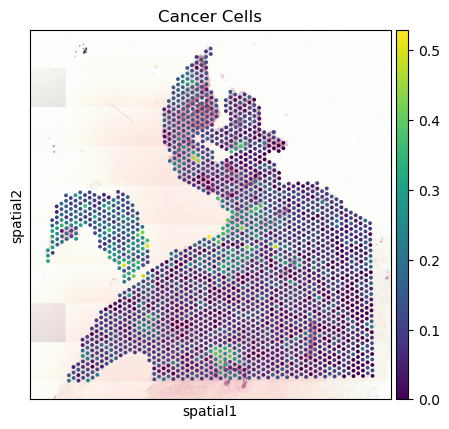

Deconvoluting Remaining Spots: 100%|██████████| 2256/2256 [11:25<00:00,  3.29it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1',
       'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'],
      dtype='object')
Parquet spot names format: ['AACAGGATTCATAGTT-1' 'AACAGGTTATTGCACC-1' 'AACAGGTTCACCGAAG-1'
 'AACAGTCAGGCTCCGC-1' 'AACAGTCCACGCGGTG-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: Macrophages_genes_pass1 (Shape: (2256, 4860))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: B_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: Fibroblasts_genes_pass1 (Shape: (2256, 4860))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (2256, 4860))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACAGGATTCATAGTT-1', 'AACAGGTTATTG

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 12251 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 423
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 423/423 [00:57<00:00,  7.37it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTTAGTCAG-1', 'AAGAATTCTGGCTGCA-1', 'AAGCAGCGGACACGTG-1', 'AAGGCCGACCTACCTG-1', 'AAGGCCGATTCTGAGC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTTAGTCAG-1', 'AAGAATTCTGGCTGCA-1', 'AAGCAGCGGACACGTG-1', 'AAGGCCGACCTACCTG-1', 'AAGGCCGATTCTGAGC-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTTAGTCAG-1', 'AAGAATTCTGGCTGCA-1', 'AAGCAGCGGACACGTG-1', 'AAGGCCGACCTACCTG-1', 'AAGGCCGATTCTGAGC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1'

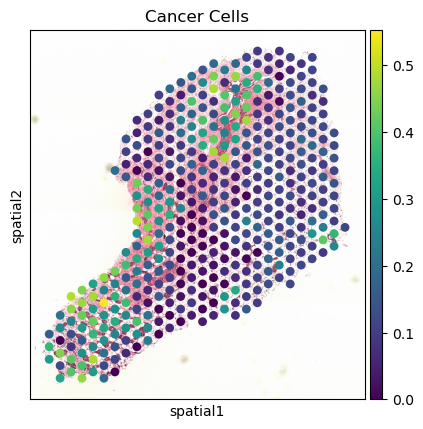

Deconvoluting Remaining Spots: 100%|██████████| 423/423 [01:27<00:00,  4.81it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1',
       'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACTATGCTGCATTCG-1' 'AACTCAACCTTGACCA-1'
 'AACTGCCTCGATAGGT-1' 'AACTTCAGATACTACC-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: Macrophages_genes_pass1 (Shape: (423, 12251))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: B_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: Fibroblasts_genes_pass1 (Shape: (423, 12251))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (423, 12251))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACTATGCTGCA

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2622 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 1783
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 1783/1783 [02:52<00:00, 10.31it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATAGTCTATCTAC-1', 'AACATGACGCAGCGTG-1', 'AACCACTGCCATAGCC-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATAGTCTATCTAC-1', 'AACATGACGCAGCGTG-1', 'AACCACTGCCATAGCC-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATAGTCTATCTAC-1', 'AACATGACGCAGCGTG-1', 'AACCACTGCCATAGCC-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'

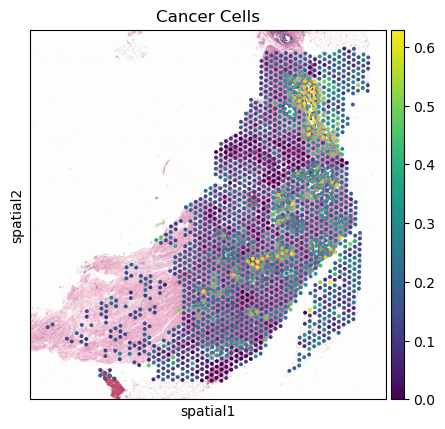

Deconvoluting Remaining Spots: 100%|██████████| 1783/1783 [05:45<00:00,  5.16it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1',
       'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACAGGATTCATAGTT-1' 'AACAGGTTCACCGAAG-1'
 'AACAGTCAGGCTCCGC-1' 'AACAGTCCACGCGGTG-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: Macrophages_genes_pass1 (Shape: (1783, 2622))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: B_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: Fibroblasts_genes_pass1 (Shape: (1783, 2622))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (1783, 2622))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGATTCAT

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 8632 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 320
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 320/320 [00:40<00:00,  7.83it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCCTACTC-1', 'AATTGCATTGAAGAAT-1', 'AATTGGTTATGATACA-1', 'ACAGGAACTACAGAAC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCCTACTC-1', 'AATTGCATTGAAGAAT-1', 'AATTGGTTATGATACA-1', 'ACAGGAACTACAGAAC-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCCTACTC-1', 'AATTGCATTGAAGAAT-1', 'AATTGGTTATGATACA-1', 'ACAGGAACTACAGAAC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1'

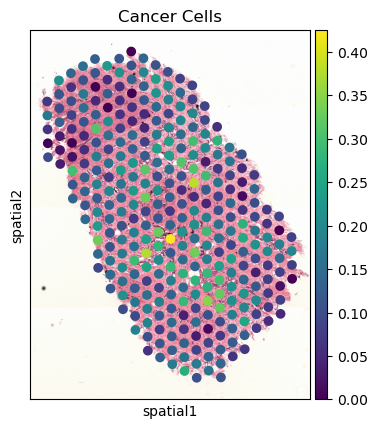

Deconvoluting Remaining Spots: 100%|██████████| 320/320 [01:00<00:00,  5.30it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1',
       'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACCGCCAGACTACTT-1' 'AACTGCCTCGATAGGT-1'
 'AAGGCCGACCTACCTG-1' 'AAGTACTGGATGCGCA-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: Macrophages_genes_pass1 (Shape: (320, 8632))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: B_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: Fibroblasts_genes_pass1 (Shape: (320, 8632))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (320, 8632))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1'

In [5]:
import importlib

import model
import scanpy as sc
import squipy as sq

importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module

# Reload the model module if you're actively developing


for path in biopsy_responding_paths:
    adata = sq.read.visium(path, counts_file="filtered_feature_bc_matrix.h5", load_images=True, gex_only=False)

    sample_name = path.split("/")[-1]

    # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder="output")

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi(LICENSE_FILE)

    global_cell_type_proportions_df, finetuned_cell_type_proportions_df = model.run_cell_proportion_model(radius=400)

    # Plot cell proportions (Append cell proportions)
    model.append_proportions_to_adata(key="global")

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions)
    model.append_proportions_to_adata(key="finetuned")

    prop_adata = model.get_adata()

    sc.pl.spatial(prop_adata, color="Cancer Cells")

    pass1_results = model.run_cell_expression_pass1(
        radius=400, max_workers=None, checkpoint_interval=100, output_dir="checkpoints", rerun=True
    )

    # Plot cell proportions (Append cell proportions)
    model.append_gex_to_adata(pass_number=1)

    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

## Surgical Specimens

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 6544 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4992
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 4992/4992 [08:49<00:00,  9.42it/s]



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


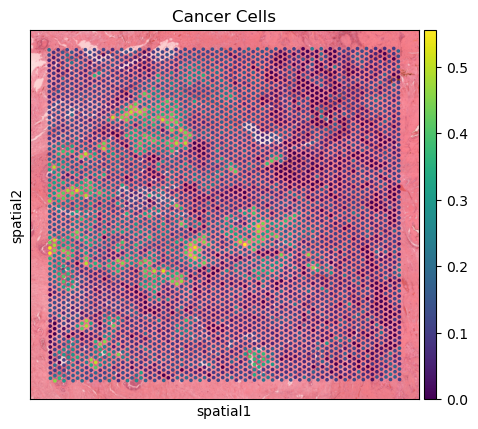

Deconvoluting Remaining Spots: 100%|██████████| 4992/4992 [55:44<00:00,  1.49it/s]  


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1',
       'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'],
      dtype='object')
Parquet spot names format: ['AACACCTACTATCGAA-1' 'AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1'
 'AACAGGAAGAGCATAG-1' 'AACAGGATTCATAGTT-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: Macrophages_genes_pass1 (Shape: (4992, 6544))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: B_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: Fibroblasts_genes_pass1 (Shape: (4992, 6544))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (4992, 6544))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATC

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9527 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4847
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 4847/4847 [11:32<00:00,  7.00it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCGTGTCGCGG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCGTGTCGCGG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCGTGTCGCGG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'

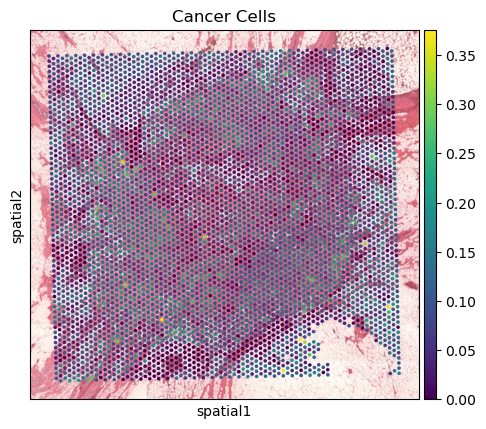

Deconvoluting Remaining Spots: 100%|██████████| 4847/4847 [1:10:11<00:00,  1.15it/s]  


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1',
       'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'],
      dtype='object')
Parquet spot names format: ['AACACCTACTATCGAA-1' 'AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1'
 'AACAGGAAGAGCATAG-1' 'AACAGGATTCATAGTT-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: Macrophages_genes_pass1 (Shape: (4847, 9527))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: B_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: Fibroblasts_genes_pass1 (Shape: (4847, 9527))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (4847, 9527))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATC

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2564 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4450
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 4450/4450 [11:13<00:00,  6.61it/s]



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


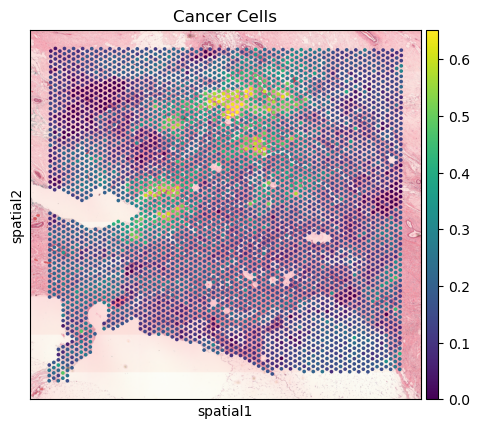

Deconvoluting Remaining Spots: 100%|██████████| 4450/4450 [22:12<00:00,  3.34it/s]  


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1',
       'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'],
      dtype='object')
Parquet spot names format: ['AACACCTACTATCGAA-1' 'AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1'
 'AACAGGAAGAGCATAG-1' 'AACAGGATTCATAGTT-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: Macrophages_genes_pass1 (Shape: (4450, 2564))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: B_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: Fibroblasts_genes_pass1 (Shape: (4450, 2564))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (4450, 2564))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATC

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9509 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4824
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions:  39%|███▉      | 1878/4824 [04:03<06:21,  7.72it/s]


In [ ]:
import importlib

import model
import scanpy as sc

importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module

# Reload the model module if you're actively developing


for path in surg_responding_paths:
    adata = sc.read_visium(path, count_file="filtered_feature_bc_matrix.h5", load_images=True, gex_only=False)

    sample_name = path.split("/")[-1]

    # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder="output")

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi(LICENSE_FILE)

    global_cell_type_proportions_df, finetuned_cell_type_proportions_df = model.run_cell_proportion_model(radius=400)

    # Plot cell proportions (Append cell proportions)
    model.append_proportions_to_adata(key="global")

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions)
    model.append_proportions_to_adata(key="finetuned")

    prop_adata = model.get_adata()

    sc.pl.spatial(prop_adata, color="Cancer Cells")

    pass1_results = model.run_cell_expression_pass1(
        radius=400, max_workers=None, checkpoint_interval=100, output_dir="checkpoints", rerun=True
    )

    # Plot cell proportions (Append cell proportions)
    model.append_gex_to_adata(pass_number=1)

    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

# Analyzing Macrophage Behavior (Load from saved files so samples don't have to be re-run)

In [22]:
import importlib
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

In [23]:
import importlib

import model
import scanpy as sc

importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module

# Reload the model module if you're actively developing

In [24]:
import os

# Core Biopsies
biopsy_responding_paths = [
    os.path.join(DATA_FOLDER, "HCC22-088-P2-S1/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P3-S1_A/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P5-S1/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P6-S1/outs"),
]

# Surgical Specimens Only For Now
surg_responding_paths = [
    os.path.join(DATA_FOLDER, "HCC22-088-P2-S2/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P3-S2/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P5-S2_F_rep/outs"),
    os.path.join(DATA_FOLDER, "HCC22-088-P6-S2_D/outs"),
]

In [25]:
cell_profiles = {
    "Cancer Cells": {"Major": ["EPCAM-1"], "Minor": ["SDC1-1", "KRT5-1"]},  # CD138 - possible cancer stem cell marker
    "Macrophages": {
        "Major": ["CD68-1"],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"],  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    },
}

In [26]:
import squidpy as sq

In [27]:
biopsy_adatas = {}

for path in biopsy_responding_paths:
    adata = sq.read.visium(path, counts_file="filtered_feature_bc_matrix.h5", load_images=True, gex_only=False)

    sample_name = path.split("/")[-2]

    # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder="output")

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi(LICENSE_FILE)

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions)
    model.append_proportions_to_adata(key="finetuned")

    # Plot cell proportions (Append cell proportions)
    model.append_gex_to_adata(pass_number=1)

    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

    biopsy_adatas[sample_name] = prop_gex_adata

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 4860 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 1898 Filtered spots: 2256 to 1898
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTA

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 12251 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 420 Filtered spots: 423 to 420
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTT

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2622 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 935 Filtered spots: 2142 to 935
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1', 'AACCTAAGAT

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 8632 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 300 Filtered spots: 328 to 300
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCC

In [29]:
surg_adatas = {}

for path in surg_responding_paths:
    adata = sq.read.visium(path, counts_file="filtered_feature_bc_matrix.h5", load_images=True, gex_only=False)

    sample_name = path.split("/")[-2]

    # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder="output")

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi(LICENSE_FILE)

    # Plot cell proportions (Append cell proportions)
    model.append_proportions_to_adata(key="global")

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions)
    model.append_proportions_to_adata(key="finetuned")

    # Plot cell proportions (Append cell proportions)
    model.append_gex_to_adata(pass_number=1)

    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

    surg_adatas[sample_name] = prop_gex_adata

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 6544 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4590 Filtered spots: 4992 to 4590
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAG

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9527 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4449 Filtered spots: 4858 to 4449
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAG

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2564 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4267 Filtered spots: 4450 to 4267
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAG

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9509 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4773 Filtered spots: 4824 to 4773
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAG

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


HCC22-088-P2-S2


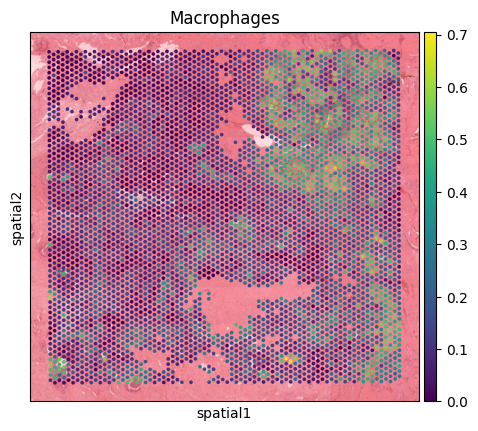

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


HCC22-088-P3-S2


<Figure size 640x480 with 0 Axes>

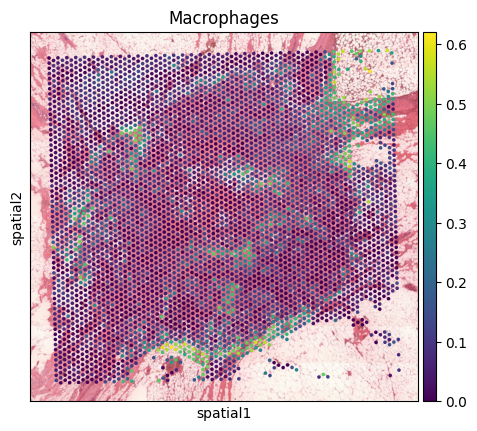

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


HCC22-088-P5-S2_F_rep


<Figure size 640x480 with 0 Axes>

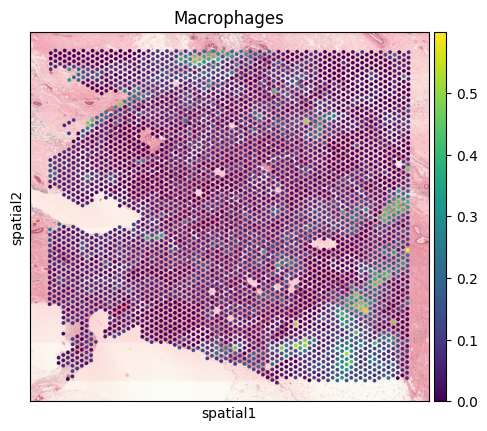

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


HCC22-088-P6-S2_D


<Figure size 640x480 with 0 Axes>

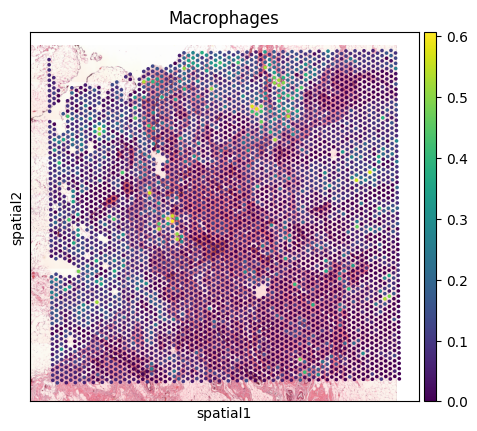

<Figure size 640x480 with 0 Axes>

In [30]:
import matplotlib.pyplot as plt

for sample_name, adata in surg_adatas.items():
    print(sample_name)
    sc.pl.spatial(adata, color="Macrophages")
    plt.savefig(f"{sample_name}_macrophages.svg")

## Harmony Integration
 
Using Harmony, we integrate data from biopsy and surgical specimens to correct for batch effects while preserving biological variation. This integration:
 - Aligns shared cell populations between conditions
 - Maintains condition-specific differences in macrophage states
 - Enables joint analysis of macrophage phenotypes across timepoints
 - Reduces technical variation while preserving biological signals

In [31]:
all_adatas = []

for sample_name, adata in biopsy_adatas.items():
    # Filter down to the spots where Macrophage Proportion is greater than 0.2
    macrophage_adata = adata[adata.obs["Macrophages"] > 0.2]
    # Then set the X matrix to the Macrophage layers
    macrophage_adata.X = macrophage_adata.layers["Macrophages_genes_pass1"]
    macrophage_adata.obs["sample_name"] = sample_name
    macrophage_adata.obs["condition"] = "Biopsy"
    all_adatas.append(macrophage_adata)


for sample_name, adata in surg_adatas.items():

    # Filter down to the spots where Macrophage Proportion is greater than 0.2
    macrophage_adata = adata[adata.obs["Macrophages"] > 0.2]
    # Then set the X matrix to the Macrophage layers
    macrophage_adata.X = macrophage_adata.layers["Macrophages_genes_pass1"]
    macrophage_adata.obs["sample_name"] = sample_name
    macrophage_adata.obs["condition"] = "Surgery"
    all_adatas.append(macrophage_adata)

    print(sample_name)

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:617: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_140578/1253406592.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name
/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:617: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, pleas

/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:617: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_140578/1253406592.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name


HCC22-088-P2-S2


/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:617: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_140578/1253406592.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name


HCC22-088-P3-S2
HCC22-088-P5-S2_F_rep
HCC22-088-P6-S2_D


/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:617: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_140578/1253406592.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name
/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:617: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, plea

In [32]:
import anndata as ad
import numpy as np

adata_spots = 0

for adata in all_adatas:
    adata_spots += adata.shape[0]

print(adata_spots)

# Create concatenated AnnData object
combined_adata = ad.concat(all_adatas, join="outer", merge="unique")  # Use outer join to keep all genes

assert adata_spots == combined_adata.shape[0]
combined_adata.obs_names_make_unique()
print(combined_adata.obs_names)
print(combined_adata.obs["condition"].unique())
print(combined_adata.obs["sample_name"])

combined_adata.X = np.nan_to_num(combined_adata.X, nan=0)

3645


/ix1/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/CITEgeist_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Index(['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1',
       'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1', 'AACCTACCTACCGGTT-1',
       'AACCTACTGTAACTCA-1', 'AACGAAGCGTGGAAGT-1', 'AACGAGCTAATAACTA-1',
       'AACGCACTGGTGCTCG-1',
       ...
       'TGGCCAAGCTGGCACC-1', 'TGGCGAATTCTATGGT-1-1', 'TGGCGAGCCACTAGCG-1',
       'TGGTATTAGCTAGACC-1', 'TGGTCGAGATCTGTAA-1', 'TGGTGCATTGTAATCC-1-2',
       'TGTAATGCCTAACACC-1', 'TGTAGGTCTGAACGCA-1-2', 'TGTCAACTCATCAACG-1-1',
       'TGTTGGAACGAGGTCA-1'],
      dtype='object', length=3645)
['Biopsy' 'Surgery']
AACAGGATTCATAGTT-1        HCC22-088-P2-S1
AACAGGTTATTGCACC-1        HCC22-088-P2-S1
AACAGGTTCACCGAAG-1        HCC22-088-P2-S1
AACCAATCTGGTTGGC-1        HCC22-088-P2-S1
AACCACTAACATGATT-1        HCC22-088-P2-S1
                              ...        
TGGTGCATTGTAATCC-1-2    HCC22-088-P6-S2_D
TGTAATGCCTAACACC-1      HCC22-088-P6-S2_D
TGTAGGTCTGAACGCA-1-2    HCC22-088-P6-S2_D
TGTCAACTCATCAACG-1-1    HCC22-088-P6-S2_D
TGTTGGAA

In [33]:
print(combined_adata)

AnnData object with n_obs × n_vars = 3645 × 13266
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'sample_name', 'condition'
    obsm: 'spatial'
    layers: 'Endothelial_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Macrophages_genes_pass1'


In [34]:
# Calculate zero percentage - make sure to use the sparse matrix properly
threshold = 0.95
zero_pct = np.sum(combined_adata.X <= threshold, axis=1) / combined_adata.X.shape[1]
print("zero_pct shape:", zero_pct.shape)
# Now filter

print(combined_adata)
combined_adata = combined_adata[zero_pct < 0.95].copy()
print(combined_adata)

zero_pct shape: (3645,)
AnnData object with n_obs × n_vars = 3645 × 13266
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'sample_name', 'condition'
    obsm: 'spatial'
    layers: 'Endothelial_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Macrophages_genes_pass1'
AnnData object with n_obs × n_vars = 657 × 13266
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'sample_name', 'condition'
    obsm: 'spatial'
    layers: 'Endothelial_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'B_Cells_genes_pas

In [35]:
sc.pp.log1p(combined_adata)
sc.pp.pca(combined_adata)

In [37]:
import scanpy.external as sce

sce.pp.harmony_integrate(combined_adata, "sample_name")

2025-02-12 16:34:59,956 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-02-12 16:35:04,569 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-02-12 16:35:04,581 - harmonypy - INFO - Iteration 1 of 10
2025-02-12 16:35:04,626 - harmonypy - INFO - Iteration 2 of 10
2025-02-12 16:35:04,674 - harmonypy - INFO - Iteration 3 of 10
2025-02-12 16:35:04,698 - harmonypy - INFO - Iteration 4 of 10
2025-02-12 16:35:04,722 - harmonypy - INFO - Iteration 5 of 10
2025-02-12 16:35:04,747 - harmonypy - INFO - Iteration 6 of 10
2025-02-12 16:35:04,762 - harmonypy - INFO - Iteration 7 of 10
2025-02-12 16:35:04,777 - harmonypy - INFO - Iteration 8 of 10
2025-02-12 16:35:04,796 - harmonypy - INFO - Iteration 9 of 10
2025-02-12 16:35:04,821 - harmonypy - INFO - Iteration 10 of 10
2025-02-12 16:35:04,840 - harmonypy - INFO - Stopped before convergence


In [38]:
sc.set_figure_params(scanpy=True, fontsize=14)

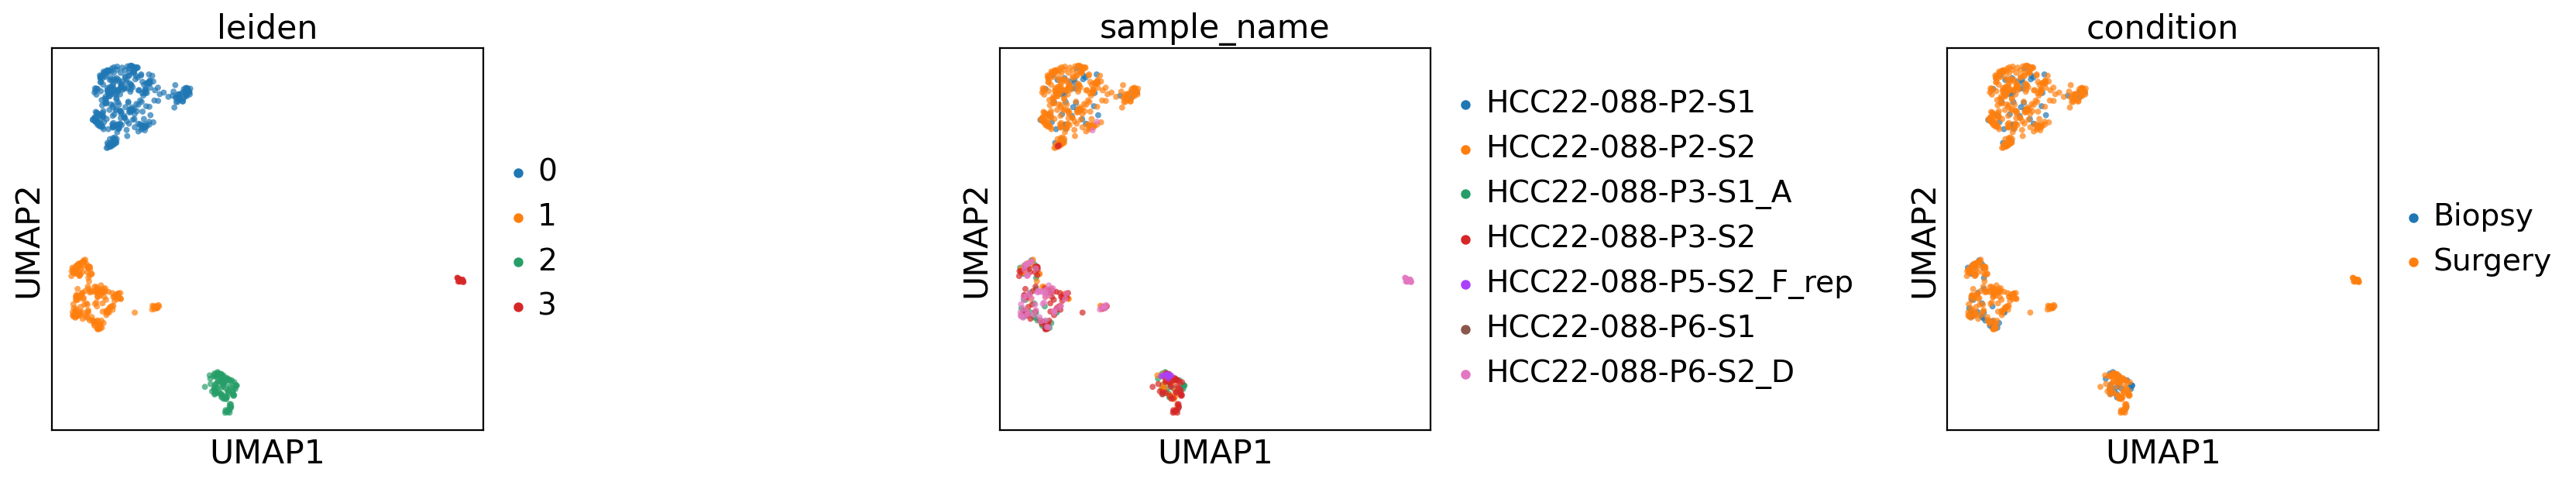

In [76]:
seed = 42

sc.pp.neighbors(combined_adata, n_neighbors=15, use_rep="X_pca_harmony", random_state=seed)
sc.tl.leiden(combined_adata, resolution=0.2, random_state=seed)
sc.tl.umap(combined_adata, min_dist=0.1, random_state=seed)
sc.pl.umap(combined_adata, color=["leiden", "sample_name", "condition"], wspace=1, size=50, alpha=0.7)

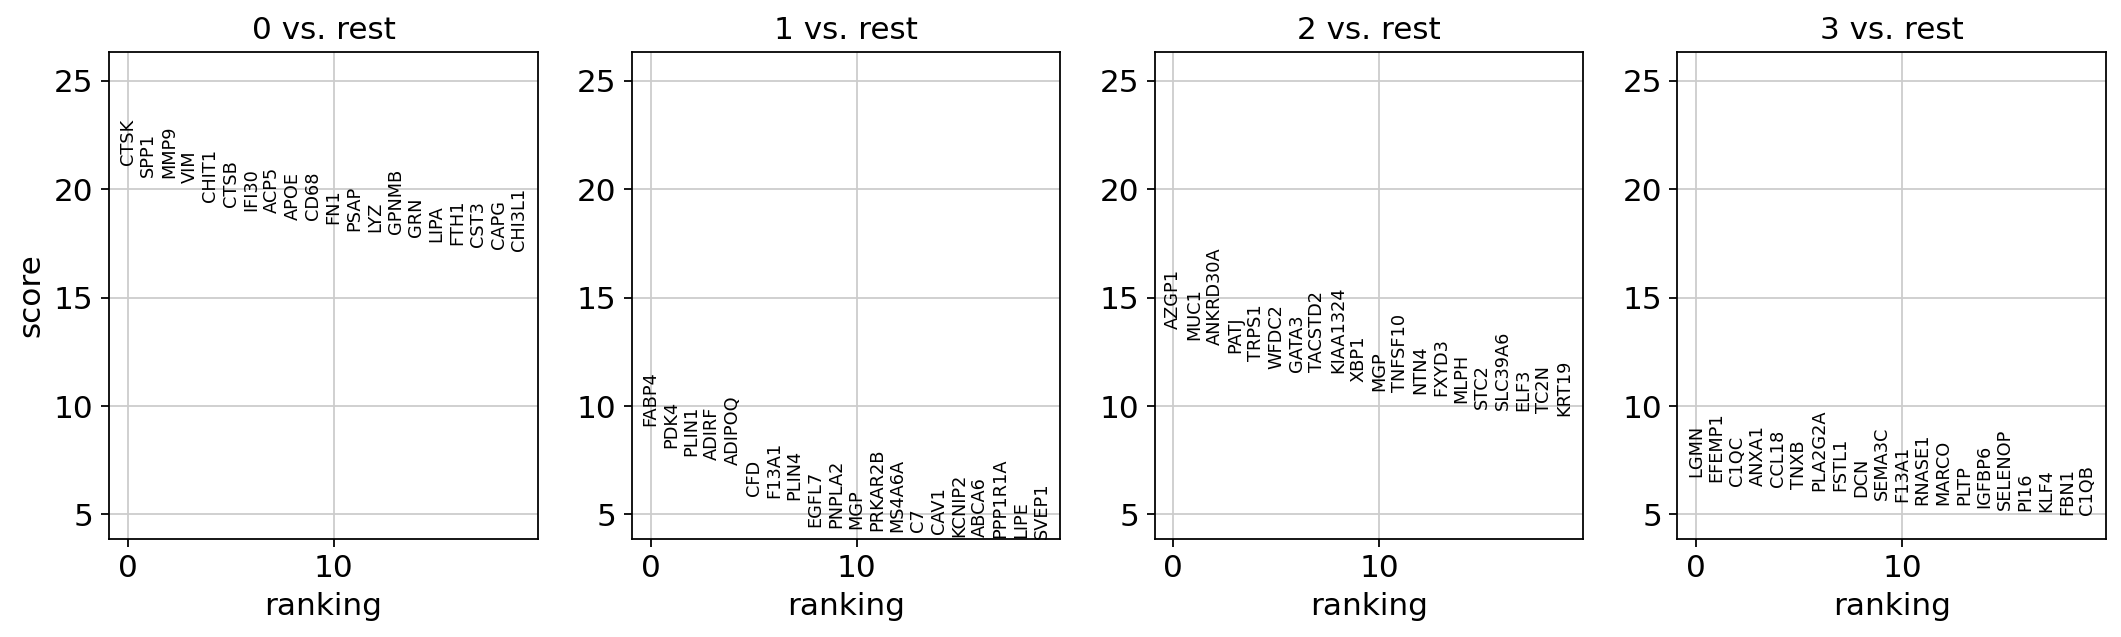

In [40]:
sc.tl.rank_genes_groups(combined_adata, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(combined_adata)

## Differential Expression Analysis

Using PyDESeq2, we perform differential expression analysis between biopsy and surgical specimens, focusing on spots with high macrophage content (>20% macrophage proportion). This analysis reveals:
- Significantly up- and down-regulated genes in surgical specimens
- Changes in macrophage phenotype between biopsy and surgery
- Key pathways involved in macrophage response to treatment

## PyDeseq2

In [41]:
print(combined_adata)

AnnData object with n_obs × n_vars = 657 × 13266
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'sample_name', 'condition', 'leiden'
    uns: 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'sample_name_colors', 'condition_colors', 'rank_genes_groups'
    obsm: 'spatial', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'Endothelial_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Macrophages_genes_pass1'
    obsp: 'distances', 'connectivities'


In [42]:
import pandas as pd
import pydeseq2

In [43]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [44]:
counts_array = np.rint(np.expm1(combined_adata.X))
counts_df = pd.DataFrame(data=counts_array, index=combined_adata.obs_names, columns=combined_adata.var_names)
print(counts_df)

                       A2M  A4GALT  AAAS  AACS  AADAT  AAGAB  AAK1  AAMDC  \
AAGACTCAAGGCTCCA-1     6.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
AAGGCGAGGTTCATGT-1    16.0     0.0   0.0   0.0    0.0    0.0   2.0    0.0   
AATCGGCGCCAACGGT-1    15.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
ACAATACGCCTTATTC-1    42.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
ACGCTCAGTGCACCGT-1    25.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
...                    ...     ...   ...   ...    ...    ...   ...    ...   
TCTTGCACGGTGAGCC-1    19.0     0.0   0.0   0.0    0.0    2.0   2.0    0.0   
TGAGACGTGAACGGTC-1     6.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
TGAGTGCAGAGGACCA-1-2   0.0     0.0   0.0  10.0    0.0    0.0   0.0    0.0   
TGCGTTAGCACGTACC-1-2   0.0     0.0   0.0   0.0    0.0    6.0   0.0    0.0   
TGTTGGAACGAGGTCA-1     0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   

                      AAMP  AAR2  ...  ZUP1  ZW10  ZWILCH  ZWINT  ZXDB  ZXD

In [45]:
sample_name = combined_adata.obs["sample_name"]
condition = combined_adata.obs["condition"]
print(sample_name.shape)
print(condition.shape)


# Ensure indices are identical before merging
if not sample_name.index.equals(condition.index):
    raise ValueError("Indices do not match between DataFrames!")
else:
    metadata_df = pd.concat([sample_name, condition], axis=1)

    print(metadata_df.shape)

(657,)
(657,)
(657, 2)


In [46]:
print(counts_df.shape)
print(metadata_df.shape)
print(metadata_df)

(657, 13266)
(657, 2)
                            sample_name condition
AAGACTCAAGGCTCCA-1      HCC22-088-P2-S1    Biopsy
AAGGCGAGGTTCATGT-1      HCC22-088-P2-S1    Biopsy
AATCGGCGCCAACGGT-1      HCC22-088-P2-S1    Biopsy
ACAATACGCCTTATTC-1      HCC22-088-P2-S1    Biopsy
ACGCTCAGTGCACCGT-1      HCC22-088-P2-S1    Biopsy
...                                 ...       ...
TCTTGCACGGTGAGCC-1    HCC22-088-P6-S2_D   Surgery
TGAGACGTGAACGGTC-1    HCC22-088-P6-S2_D   Surgery
TGAGTGCAGAGGACCA-1-2  HCC22-088-P6-S2_D   Surgery
TGCGTTAGCACGTACC-1-2  HCC22-088-P6-S2_D   Surgery
TGTTGGAACGAGGTCA-1    HCC22-088-P6-S2_D   Surgery

[657 rows x 2 columns]


genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]

In [47]:
metadata_df = metadata_df.loc[counts_df.index]

In [48]:
print(counts_df.shape)
print(metadata_df.shape)

(657, 13266)
(657, 2)


In [49]:
inference = DefaultInference(n_cpus=16)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="~condition",
    refit_cooks=True,
    inference=inference,
    size_factors_fit_type="poscounts",
)

In [50]:
dds.deseq2()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.20 seconds.

Fitting dispersions...
... done in 1.79 seconds.

Fitting dispersion trend curve...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 1.46 seconds.

Fitting LFCs...
... done in 1.68 seconds.

Calculating cook's distance...
... done in 0.81 seconds.

Replacing 17 outlier genes.

Fitting dispersions...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.



In [51]:
ds = DeseqStats(
    dds,
    contrast=np.array([0, 1]),
    alpha=0.05,
    cooks_filter=True,
    independent_filter=True,
)

In [52]:
type(ds.summary())

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0 1]
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M     12.520335       -0.586082  0.182556 -3.210424  0.001325  0.048270
A4GALT   0.029086       -0.673362  3.812757 -0.176608  0.859817       NaN
AAAS     0.789660        1.059488  0.544429  1.946055  0.051648  0.324158
AACS     0.546659       -0.479842  0.601084 -0.798295  0.424700       NaN
AADAT    0.170546       -0.120861  1.256823 -0.096164  0.923390       NaN
...           ...             ...       ...       ...       ...       ...
ZXDC     0.248568       -0.296141  1.039170 -0.284978  0.775661       NaN
ZYG11A   0.000000             NaN       NaN       NaN       NaN       NaN
ZYG11B   0.621685        1.021241  0.595927  1.713701  0.086584       NaN
ZYX      4.737238       -0.144539  0.258449 -0.559257  0.575986  0.810668
ZZEF1    0.889280        0.503155  0.494775  1.016938  0.309183  0.633179

[13266 rows x 6 columns]


... done in 8.03 seconds.



NoneType

In [53]:
df = ds.results_df

In [54]:
print(df)

de_df = df.copy()

df.to_csv("deseq2_results.csv", index=True)

         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M     12.520335       -0.586082  0.182556 -3.210424  0.001325  0.048270
A4GALT   0.029086       -0.673362  3.812757 -0.176608  0.859817       NaN
AAAS     0.789660        1.059488  0.544429  1.946055  0.051648  0.324158
AACS     0.546659       -0.479842  0.601084 -0.798295  0.424700       NaN
AADAT    0.170546       -0.120861  1.256823 -0.096164  0.923390       NaN
...           ...             ...       ...       ...       ...       ...
ZXDC     0.248568       -0.296141  1.039170 -0.284978  0.775661       NaN
ZYG11A   0.000000             NaN       NaN       NaN       NaN       NaN
ZYG11B   0.621685        1.021241  0.595927  1.713701  0.086584       NaN
ZYX      4.737238       -0.144539  0.258449 -0.559257  0.575986  0.810668
ZZEF1    0.889280        0.503155  0.494775  1.016938  0.309183  0.633179

[13266 rows x 6 columns]


In [55]:
# Volcano plot
print(dds.variables)  # Shows variables in your model

{'condition'}


In [56]:
import pandas as pd

df = pd.read_csv("deseq2_results.csv", index_col=0)
de_df = df.copy()

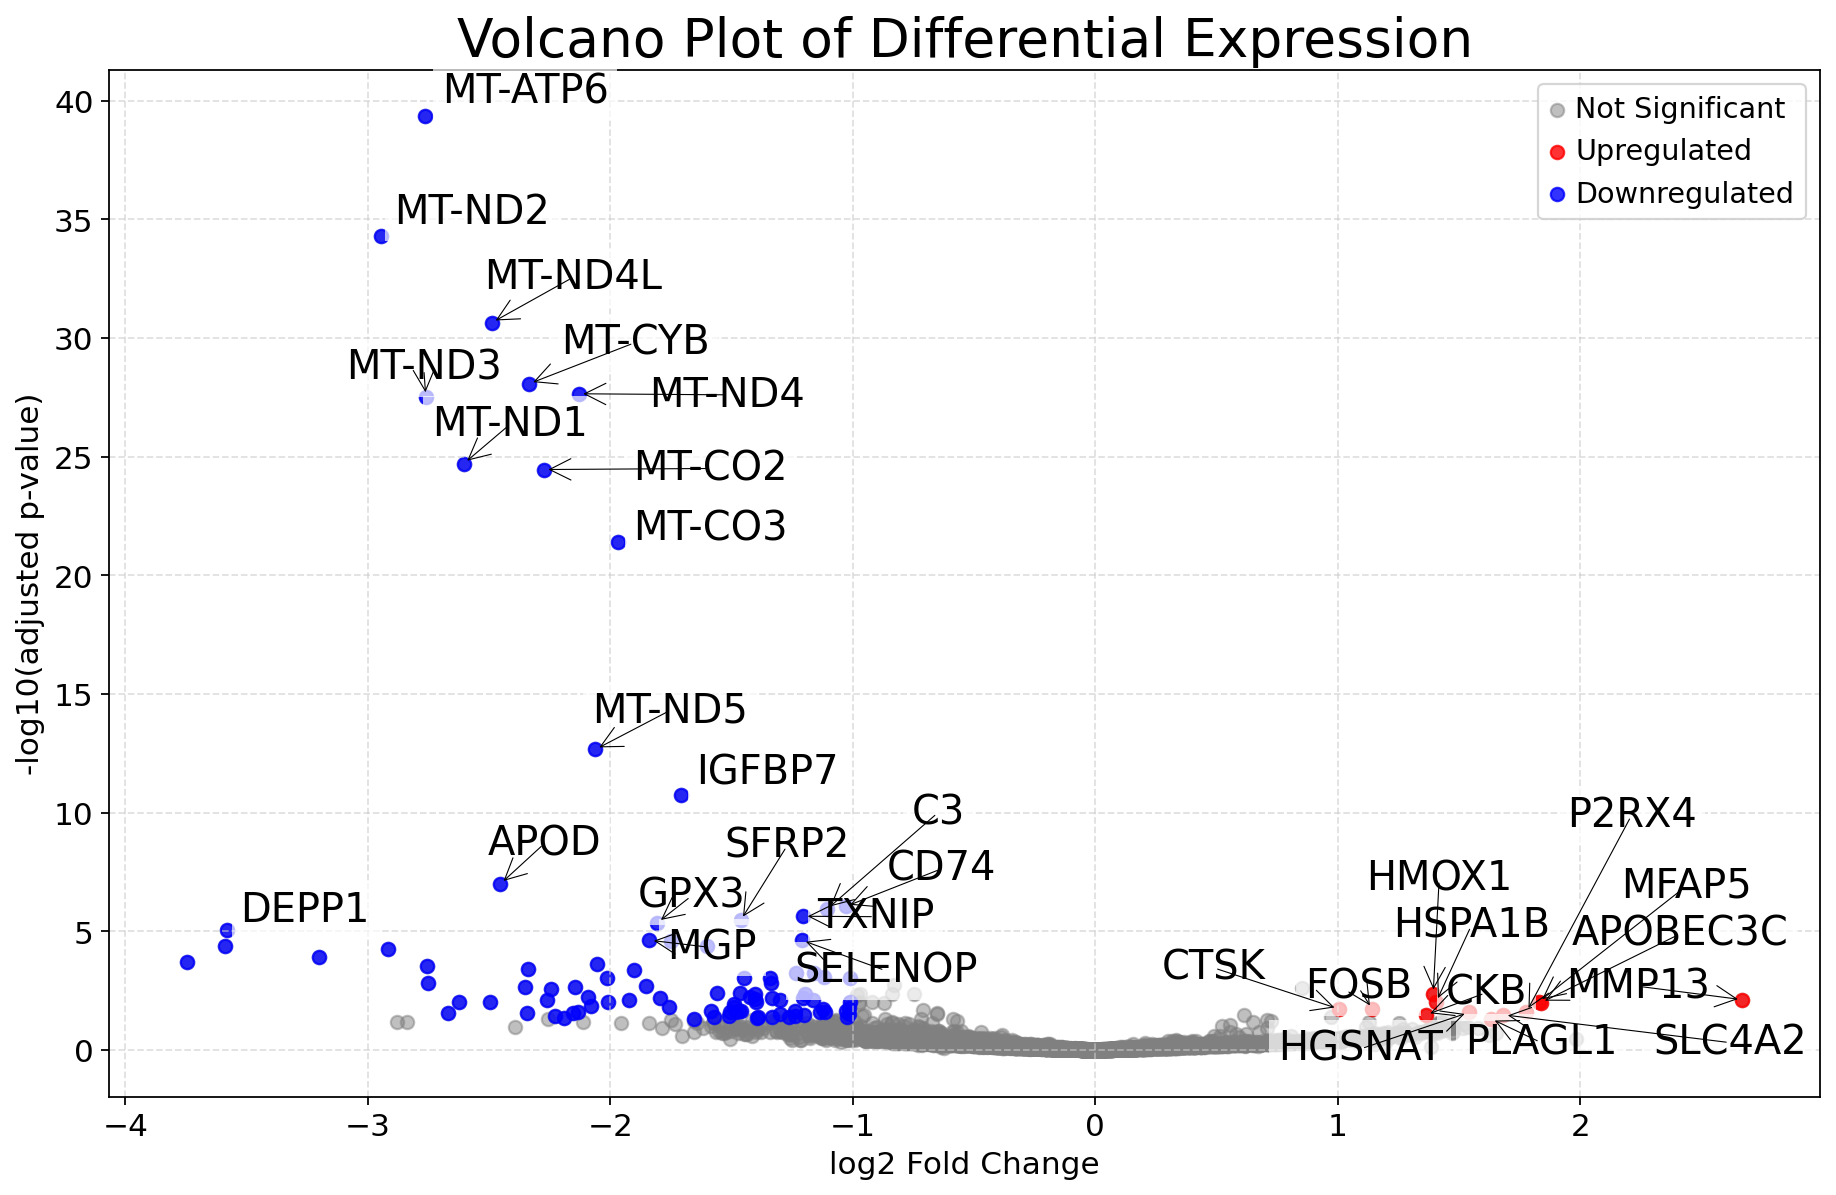


Number of significantly upregulated genes: 12
Number of significantly downregulated genes: 95


In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from adjustText import adjust_text

# Set fontsize for all plots in matplotlib
plt.rcParams.update({"font.size": 24})


# Assuming your dataframe is called 'df'
# Create a boolean mask for significant genes
df["significant"] = (df["padj"] < 0.05) & (abs(df["log2FoldChange"]) > 1)

# Create the volcano plot
plt.figure(figsize=(12, 8))

# Plot all points in gray first
plt.scatter(df["log2FoldChange"], -np.log10(df["padj"]), color="gray", alpha=0.5, label="Not Significant")

# Highlight significant genes
significant_genes = df[df["significant"]]

# Split into up and down regulated
upregulated = significant_genes[significant_genes["log2FoldChange"] > 1]
downregulated = significant_genes[significant_genes["log2FoldChange"] < -1]

# Plot significant points
plt.scatter(upregulated["log2FoldChange"], -np.log10(upregulated["padj"]), color="red", alpha=0.8, label="Upregulated")

plt.scatter(
    downregulated["log2FoldChange"], -np.log10(downregulated["padj"]), color="blue", alpha=0.8, label="Downregulated"
)

# Create list to store all text objects
texts = []

# Label top n up and down regulated genes separately
n_per_direction = 20  # Number of top genes to label in each direction

# For upregulated genes
top_up = upregulated.sort_values("padj").head(n_per_direction)
for idx, row in top_up.iterrows():
    texts.append(
        plt.text(
            row["log2FoldChange"],
            -np.log10(row["padj"]),
            idx,
            fontsize=18,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
        )
    )

# For downregulated genes
top_down = downregulated.sort_values("padj").head(n_per_direction)
for idx, row in top_down.iterrows():
    texts.append(
        plt.text(
            row["log2FoldChange"],
            -np.log10(row["padj"]),
            idx,
            fontsize=18,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
        )
    )

# Adjust text positions to prevent overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="black", lw=0.5), expand_points=(1.5, 1.5))

# Add labels and title
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot of Differential Expression", fontsize=24)

# Add a legend
plt.legend()

# Add grid
plt.grid(True, linestyle="--", alpha=0.6)

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.savefig("vignette_3_volcano_plot.svg")

# Show the plot
plt.show()


# Print statistics
print(f"\nNumber of significantly upregulated genes: {len(upregulated)}")
print(f"Number of significantly downregulated genes: {len(downregulated)}")
gene_dict = {"Upregulated": upregulated, "Downregulated": downregulated}

In [59]:
downregulated

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
ACACB,0.786470,-2.753140,0.630655,-4.365524,1.268185e-05,0.001468,True
ADH1B,0.890353,-3.199730,0.644947,-4.961226,7.004960e-07,0.000127,True
ADIPOQ,2.104325,-2.757077,0.578417,-4.766587,1.873725e-06,0.000302,True
ADIRF,3.122664,-1.904513,0.406556,-4.684506,2.806364e-06,0.000422,True
AGPAT2,0.752107,-2.190372,0.674619,-3.246828,1.166989e-03,0.043555,True
...,...,...,...,...,...,...,...
TACSTD2,1.988651,-2.245209,0.535802,-4.190371,2.784984e-05,0.002795,True
TOMM7,2.927949,-1.196043,0.293095,-4.080731,4.489431e-05,0.004224,True
TXNIP,9.562188,-1.204783,0.208673,-5.773557,7.761539e-09,0.000002,True
UBB,1.754469,-1.238388,0.374941,-3.302886,9.569527e-04,0.038053,True


## Phagocytosis Gene Signature Analysis

We examine the enrichment of phagocytosis-related genes using a known mouse TAM gene signature:
1. Convert mouse gene signatures to human orthologs
2. Compare expression patterns between biopsy and surgical specimens
3. Analyze correlation between mouse phagocytosis signatures and human surgical changes


In [61]:
import pandas as pd

df = pd.read_excel("examples/JEM_20221472_TableS4.xlsx", sheet_name="SuppTable4")

df.columns = df.iloc[1]

df = df.iloc[2:]


df.rename(columns={"GeneSymbol": "mouse_gene_symbol"}, inplace=True)

print(df)

print(df.columns)

1    mouse_gene_symbol p.value  fdr tdTom-pos.estimated.mean  \
2                Mmp12     0.0  0.0                 1.950867   
3                 Ctss     0.0  0.0                 3.956765   
4                 C1qb     0.0  0.0                 1.507692   
5                Rps28     0.0  0.0                 4.006531   
6                 Ctsc     0.0  0.0                 1.947687   
...                ...     ...  ...                      ...   
9549          Mettl5os     1.0  1.0                 0.012896   
9550             Skap1     1.0  1.0                 0.011459   
9551            March4     1.0  1.0                 0.011505   
9552             Rasef     1.0  1.0                 0.008805   
9553            Ighg2b     1.0  1.0                 0.004657   

1    tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
2                    0.929998        1.020868  0.789537    1.2522    0.581161   
3                    2.993281        0.963484  0.738412  1.188556    

In [62]:
# Filter down to genes that have an FDR < 0.05

df = df[df["fdr"] < 0.05]

print(df)

1    mouse_gene_symbol   p.value       fdr tdTom-pos.estimated.mean  \
2                Mmp12       0.0       0.0                 1.950867   
3                 Ctss       0.0       0.0                 3.956765   
4                 C1qb       0.0       0.0                 1.507692   
5                Rps28       0.0       0.0                 4.006531   
6                 Ctsc       0.0       0.0                 1.947687   
...                ...       ...       ...                      ...   
7361             Kif11  0.049734  0.049734                 0.023967   
7362            Clec4d  0.049818  0.049818                 0.135296   
7363             Phf20  0.049877  0.049877                 0.106217   
7364             Iba57  0.049887  0.049887                 0.022905   
7365             Cdc45  0.049945  0.049945                 0.023058   

1    tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
2                    0.929998        1.020868  0.789537    1.2522 

In [64]:
from typing import List

import pandas as pd
from pybiomart import Dataset


def chunk_list(lst: List[str], chunk_size: int = 200):
    """
    Yield successive chunks of the specified size from the list.

    Args:
        lst: List of items.
        chunk_size: Maximum number of items per chunk.

    Yields:
        Slices (chunks) of the original list.
    """
    for i in range(0, len(lst), chunk_size):
        yield lst[i : i + chunk_size]


# Connect to the Ensembl mouse dataset.
mouse_dataset = Dataset(name="mmusculus_gene_ensembl", host="http://www.ensembl.org")

print(mouse_dataset.filters)

gene_ids = df["mouse_gene_symbol"].tolist()[:10]

# Query the dataset for homologs of the rat gene using 'gene_id' filter
result = mouse_dataset.query(attributes=["mgi_symbol", "ensembl_gene_id"])

print(result)


df = df.merge(result, left_on="mouse_gene_symbol", right_on="MGI symbol", how="left")

print(df)

{'link_so_mini_closure': <biomart.Filter name='link_so_mini_closure', type='list'>, 'link_go_closure': <biomart.Filter name='link_go_closure', type='text'>, 'link_ensembl_transcript_stable_id': <biomart.Filter name='link_ensembl_transcript_stable_id', type='text'>, 'gene_id': <biomart.Filter name='gene_id', type='text'>, 'transcript_id': <biomart.Filter name='transcript_id', type='text'>, 'link_ensembl_gene_id': <biomart.Filter name='link_ensembl_gene_id', type='text'>, 'chromosome_name': <biomart.Filter name='chromosome_name', type='text'>, 'start': <biomart.Filter name='start', type='text'>, 'end': <biomart.Filter name='end', type='text'>, 'band_start': <biomart.Filter name='band_start', type='drop_down_basic_filter'>, 'band_end': <biomart.Filter name='band_end', type='drop_down_basic_filter'>, 'strand': <biomart.Filter name='strand', type='text'>, 'chromosomal_region': <biomart.Filter name='chromosomal_region', type='text'>, 'id_list_xrefs_filters': <biomart.Filter name='id_list_xre

In [65]:
# Query the dataset for homologs of the rat gene using 'gene_id' filter
result = mouse_dataset.query(attributes=["ensembl_gene_id", "hsapiens_homolog_ensembl_gene"])

print(result)

           Gene stable ID Human gene stable ID
0      ENSMUSG00000064336                  NaN
1      ENSMUSG00000064337                  NaN
2      ENSMUSG00000064338                  NaN
3      ENSMUSG00000064339                  NaN
4      ENSMUSG00000064340                  NaN
...                   ...                  ...
83574  ENSMUSG00000087203                  NaN
83575  ENSMUSG00000085319                  NaN
83576  ENSMUSG00000086652                  NaN
83577  ENSMUSG00000092353                  NaN
83578  ENSMUSG00000085015                  NaN

[83579 rows x 2 columns]


In [66]:
df = df.merge(result, left_on="Gene stable ID", right_on="Gene stable ID", how="left")

print(df)

     mouse_gene_symbol   p.value       fdr tdTom-pos.estimated.mean  \
0                Mmp12       0.0       0.0                 1.950867   
1                 Ctss       0.0       0.0                 3.956765   
2                 C1qb       0.0       0.0                 1.507692   
3                Rps28       0.0       0.0                 4.006531   
4                 Ctsc       0.0       0.0                 1.947687   
...                ...       ...       ...                      ...   
7533             Kif11  0.049734  0.049734                 0.023967   
7534            Clec4d  0.049818  0.049818                 0.135296   
7535             Phf20  0.049877  0.049877                 0.106217   
7536             Iba57  0.049887  0.049887                 0.022905   
7537             Cdc45  0.049945  0.049945                 0.023058   

     tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
0                    0.929998        1.020868  0.789537    1.2522 

In [67]:
dataset = Dataset(name="hsapiens_gene_ensembl", host="http://www.ensembl.org")


result = dataset.query(attributes=["ensembl_gene_id", "external_gene_name"])

print(result)

        Gene stable ID    Gene name
0      ENSG00000210049        MT-TF
1      ENSG00000211459      MT-RNR1
2      ENSG00000210077        MT-TV
3      ENSG00000210082      MT-RNR2
4      ENSG00000209082       MT-TL1
...                ...          ...
86397  ENSG00000235358     SCMH1-DT
86398  ENSG00000228067    LINC01740
86399  ENSG00000293271  SLC44A3-AS1
86400  ENSG00000310526       WASH7P
86401  ENSG00000241860          NaN

[86402 rows x 2 columns]


In [68]:
df = df.merge(result, left_on="Human gene stable ID", right_on="Gene stable ID", how="left")
print(df)

     mouse_gene_symbol   p.value       fdr tdTom-pos.estimated.mean  \
0                Mmp12       0.0       0.0                 1.950867   
1                 Ctss       0.0       0.0                 3.956765   
2                 C1qb       0.0       0.0                 1.507692   
3                Rps28       0.0       0.0                 4.006531   
4                 Ctsc       0.0       0.0                 1.947687   
...                ...       ...       ...                      ...   
7533             Kif11  0.049734  0.049734                 0.023967   
7534            Clec4d  0.049818  0.049818                 0.135296   
7535             Phf20  0.049877  0.049877                 0.106217   
7536             Iba57  0.049887  0.049887                 0.022905   
7537             Cdc45  0.049945  0.049945                 0.023058   

     tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
0                    0.929998        1.020868  0.789537    1.2522 

In [69]:
df.to_csv("mouse_human_phagocytosis.csv", index=False)

In [70]:
print(df.head())

mouse_df = pd.read_csv("mouse_human_phagocytosis.csv")

  mouse_gene_symbol p.value  fdr tdTom-pos.estimated.mean  \
0             Mmp12     0.0  0.0                 1.950867   
1              Ctss     0.0  0.0                 3.956765   
2              C1qb     0.0  0.0                 1.507692   
3             Rps28     0.0  0.0                 4.006531   
4              Ctsc     0.0  0.0                 1.947687   

  tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
0                 0.929998        1.020868  0.789537    1.2522    0.581161   
1                 2.993281        0.963484  0.738412  1.188556    0.563748   
2                 0.706236        0.801456  0.592979  1.009934    0.506269   
3                 3.207838        0.798693  0.648395  0.948991    0.699823   
4                 1.159413        0.788274  0.629068   0.94748    0.652048   

  tdTom-pos.specificity tdTom-neg.specificity tdTom-pos.detection.rate  \
0              0.677215              0.322785                  0.48307   
1               

In [71]:
print("de_df.columns", de_df.columns)
print("mouse_df.columns", mouse_df.columns)

de_df.columns Index(['baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj'], dtype='object')
mouse_df.columns Index(['mouse_gene_symbol', 'p.value', 'fdr', 'tdTom-pos.estimated.mean',
       'tdTom-neg.estimated.mean', 'log2.foldchange', 'ci.low', 'ci.high',
       'effect.size', 'tdTom-pos.specificity', 'tdTom-neg.specificity',
       'tdTom-pos.detection.rate', 'tdTom-neg.detection.rate', 'MGI symbol',
       'Gene stable ID_x', 'Human gene stable ID', 'Gene stable ID_y',
       'Gene name'],
      dtype='object')


Initial number of human genes: 13266
Number of significant human genes (padj < 0.05): 127
Number of overlapping genes before numeric filtering: 62
Number of overlapping genes after removing NaN: 62

Phagocytosis Gene Analysis Results (Significant Genes Only):
Correlation coefficient: 0.315
Correlation p-value: 1.25e-02
Mean fold change in surgical samples: -1.245
One-sample t-test p-value: 4.19e-13
Proportion of genes upregulated: 9.68%

Top 10 most differentially expressed phagocytosis genes in surgical samples:
Gene name  log2FoldChange  pvalue  padj  log2.foldchange
 SERPINA3          -3.746   0.000 0.000            0.063
   MT-ND2          -2.945   0.000 0.000           -0.691
  MT-ATP6          -2.766   0.000 0.000           -0.643
   MT-ND3          -2.761   0.000 0.000           -0.292
   MT-ND1          -2.604   0.000 0.000           -0.393
  MT-ND4L          -2.489   0.000 0.000            0.421
   MT-CYB          -2.335   0.000 0.000           -0.516
   MT-CO2          -2.274

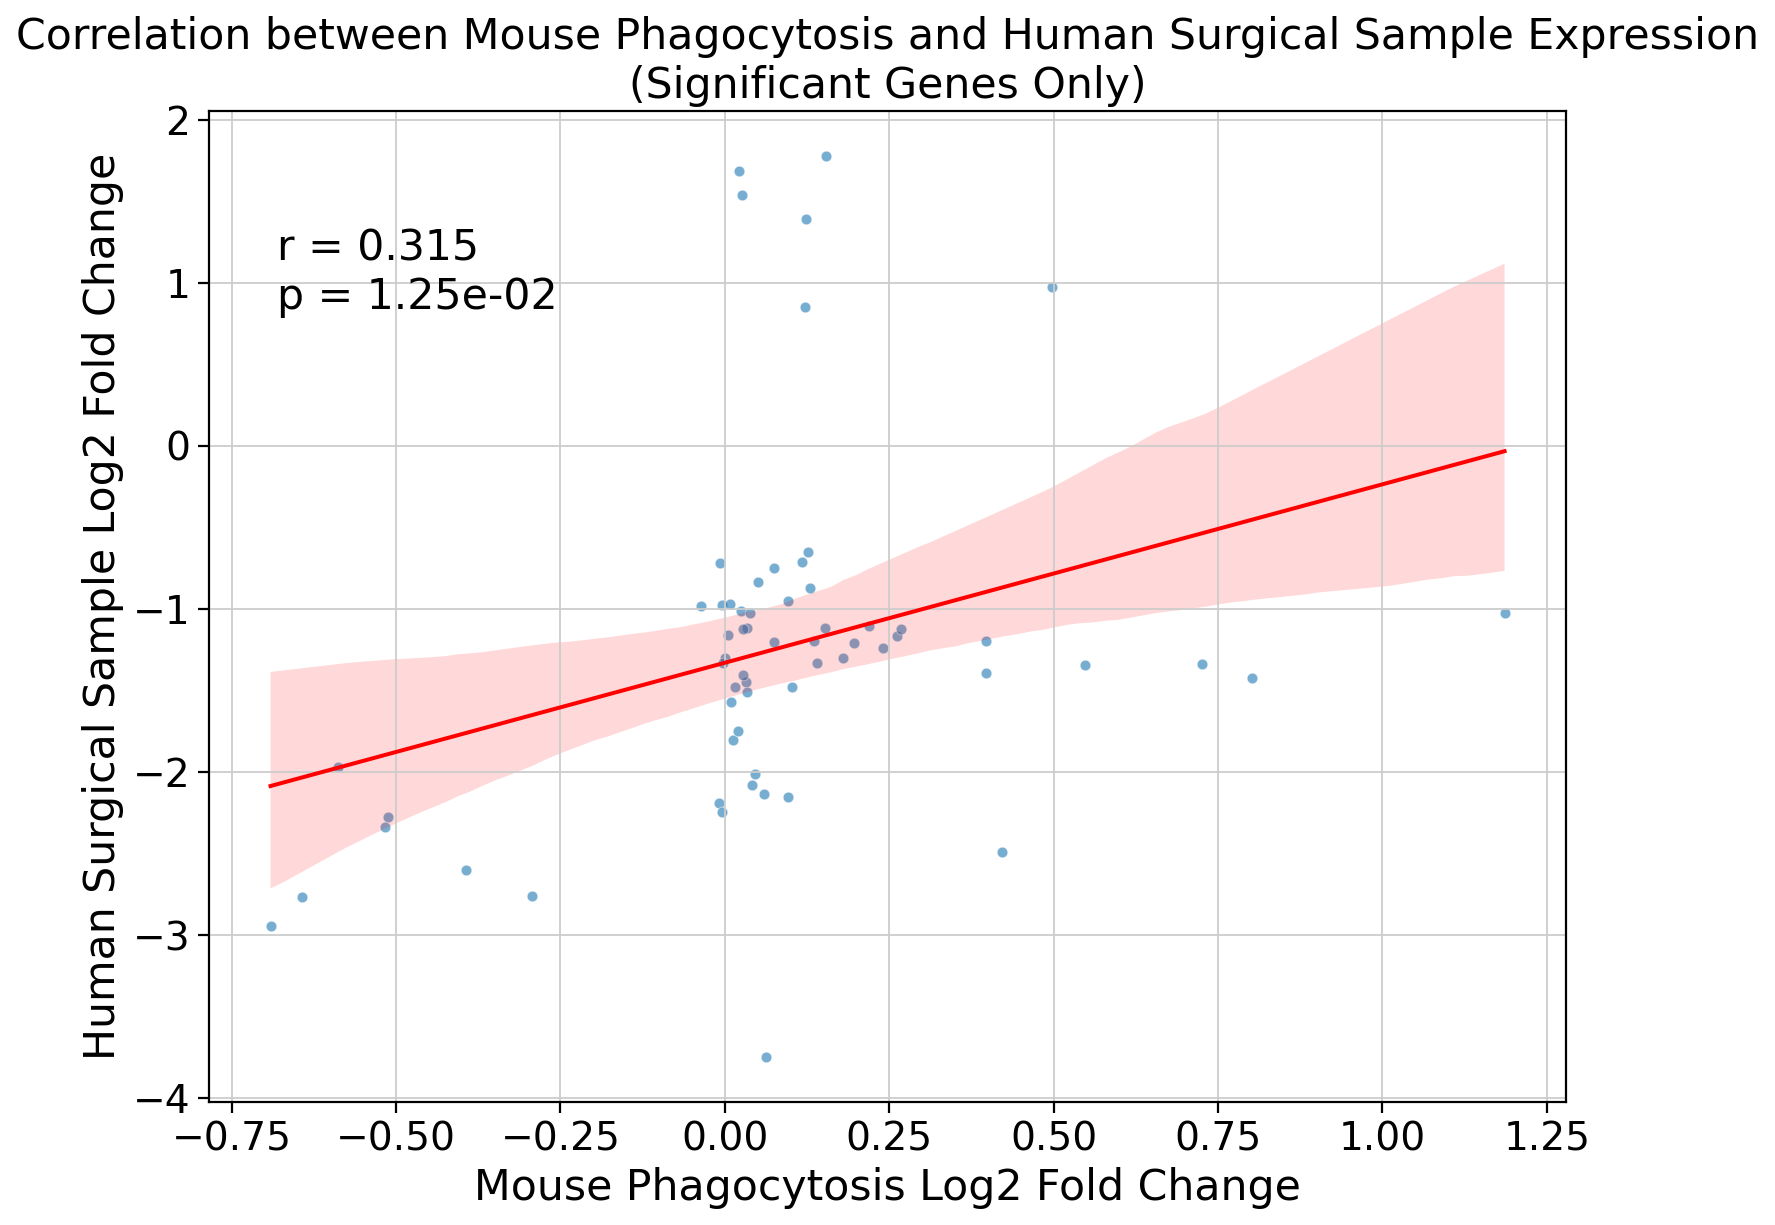

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Set fontsize for all plots in matplotlib
plt.rcParams.update({"font.size": 20})

# Set fontsize for all plots in seaborn
sns.set_context("paper", font_scale=2)


def analyze_phagocytosis_enrichment(de_df, mouse_df):
    """
    Analyze whether phagocytosis genes are enriched in surgical samples

    Parameters:
    de_df: DataFrame with human DESeq results (index should be gene names)
    mouse_df: DataFrame with mouse phagocytosis signature

    Returns:
    dict with analysis results and merged DataFrame for plotting
    """

    # Print initial number of genes
    print(f"Initial number of human genes: {len(de_df)}")

    # Filter human genes for significant adjusted p-values
    de_df = de_df[de_df["padj"].notna() & (de_df["padj"] < 0.05)].copy()
    print(f"Number of significant human genes (padj < 0.05): {len(de_df)}")

    # Create merged dataset of overlapping genes
    merged_df = pd.merge(
        de_df.reset_index().rename(columns={"index": "gene_name"}),
        mouse_df,
        left_on="gene_name",
        right_on="Gene name",
        how="inner",
    )

    # Print number of genes before filtering
    print(f"Number of overlapping genes before numeric filtering: {len(merged_df)}")

    # Convert columns to numeric, replacing non-numeric values with NaN
    merged_df["log2FoldChange"] = pd.to_numeric(merged_df["log2FoldChange"], errors="coerce")
    merged_df["log2.foldchange"] = pd.to_numeric(merged_df["log2.foldchange"], errors="coerce")
    merged_df["pvalue"] = pd.to_numeric(merged_df["pvalue"], errors="coerce")

    # Filter out rows with NaN values in key columns
    merged_df = merged_df.dropna(subset=["log2FoldChange", "log2.foldchange"])

    print(f"Number of overlapping genes after removing NaN: {len(merged_df)}")

    if len(merged_df) == 0:
        print("No overlapping genes found after filtering!")
        return None

    # Calculate correlation between mouse phagocytosis and human surgical fold changes
    correlation, p_value = stats.pearsonr(
        merged_df["log2.foldchange"].astype(float),  # Mouse phagocytosis fold change
        merged_df["log2FoldChange"].astype(float),  # Human surgical fold change
    )

    # Calculate mean fold change in surgical samples for phagocytosis genes
    mean_surgical_fc = merged_df["log2FoldChange"].mean()

    # Perform one-sample t-test to see if fold changes are significantly different from 0
    t_stat, t_pval = stats.ttest_1samp(merged_df["log2FoldChange"], 0)

    # Calculate what proportion of phagocytosis genes are upregulated in surgical samples
    n_up = (merged_df["log2FoldChange"] > 0).sum()
    n_total = len(merged_df)
    prop_up = n_up / n_total if n_total > 0 else 0

    # Create visualization
    plt.figure(figsize=(10, 8))

    # Scatter plot
    sns.scatterplot(
        data=merged_df,
        x="log2.foldchange",  # Mouse phagocytosis fold change
        y="log2FoldChange",  # Human surgical fold change
        alpha=0.6,
    )

    # Add trend line
    sns.regplot(data=merged_df, x="log2.foldchange", y="log2FoldChange", scatter=False, color="red")

    plt.title("Correlation between Mouse Phagocytosis and Human Surgical Sample Expression\n(Significant Genes Only)")
    plt.xlabel("Mouse Phagocytosis Log2 Fold Change")
    plt.ylabel("Human Surgical Sample Log2 Fold Change")

    # Add correlation annotation
    plt.annotate(f"r = {correlation:.3f}\np = {p_value:.2e}", xy=(0.05, 0.80), xycoords="axes fraction")

    # Compile results
    results = {
        "correlation": correlation,
        "correlation_pvalue": p_value,
        "mean_surgical_fc": mean_surgical_fc,
        "t_statistic": t_stat,
        "t_pvalue": t_pval,
        "n_phagocytosis_genes": n_total,
        "n_upregulated": n_up,
        "proportion_upregulated": prop_up,
        "merged_data": merged_df,
    }

    # Print summary statistics
    print("\nPhagocytosis Gene Analysis Results (Significant Genes Only):")
    print(f"Correlation coefficient: {correlation:.3f}")
    print(f"Correlation p-value: {p_value:.2e}")
    print(f"Mean fold change in surgical samples: {mean_surgical_fc:.3f}")
    print(f"One-sample t-test p-value: {t_pval:.2e}")
    print(f"Proportion of genes upregulated: {prop_up:.2%}")

    # Get top genes by absolute fold change
    top_genes = merged_df.copy()
    top_genes["abs_fc"] = abs(top_genes["log2FoldChange"])
    top_genes = top_genes.nlargest(10, "abs_fc")[
        ["Gene name", "log2FoldChange", "pvalue", "padj", "log2.foldchange"]
    ].round(3)

    print("\nTop 10 most differentially expressed phagocytosis genes in surgical samples:")
    pd.set_option("display.max_columns", None)
    print(top_genes.to_string(index=False))

    plt.tight_layout()
    plt.savefig("phagocytosis_enrichment.svg")
    return results


# Now you can run the analysis with:
results = analyze_phagocytosis_enrichment(de_df, mouse_df)